# Using QuTiP for the Quantum Teleportation curcuit

In [48]:
import numpy as np
from qutip import about, basis, tensor
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import Measurement


## Prepare the Bell state

         
 q2 :────
         
         
 q1 :────
         
         
 q0 :────
         
         
 c1 :════
         
         
 c0 :════
         
##############################################################################################################
                  ┌──────┐   
 q2 :─────────────┤ CNOT ├───
                  └───┬──┘   
        ┌──────┐      │      
 q1 :───┤ SNOT ├──────█──────
        └──────┘             
                             
 q0 :────────────────────────
                             
                             
 c1 :════════════════════════
                             
                             
 c0 :════════════════════════
                             
##############################################################################################################
                  ┌──────┐                       
 q2 :─────────────┤ CNOT ├───────────────────────
                  └───┬──┘                       
        ┌──────┐      │     

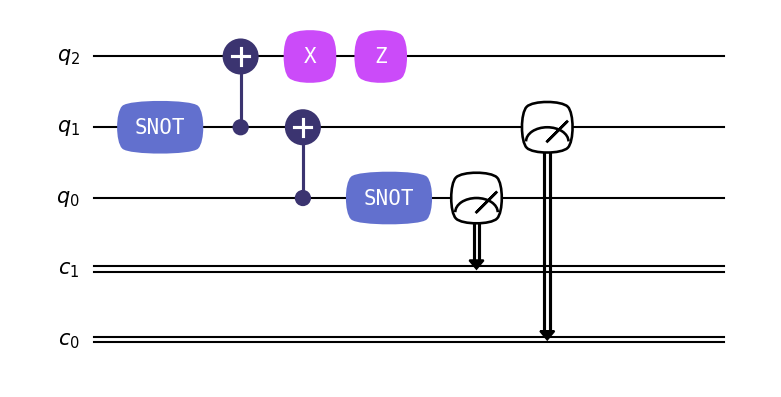

In [49]:
teleportation = QubitCircuit(3,
                             num_cbits=2, 
                             input_states=[r"\psi", "0", "0", "c0", "c1"],
                             )
teleportation.draw("text")
print("#"*110)

# Create entagled pair
teleportation.add_gate("SNOT", targets=1)
teleportation.add_gate("CNOT", targets=2, controls=1,)
teleportation.draw("text")
print("#"*110)

teleportation.add_gate("CNOT", targets=1, controls=0)
teleportation.add_gate("SNOT", targets=0)
teleportation.draw("text")
print("#"*110)

teleportation.add_measurement("M0", targets=0, classical_store=1)
teleportation.add_measurement("M1", targets=1, classical_store=0)
teleportation.draw("text")
print("#"*110)

# Add gates based on measurement results
teleportation.add_gate("X", targets=2, classical_controls=0)
teleportation.add_gate("Z", targets=2, classical_controls=1)
teleportation

## Example 1

In [50]:
p = (basis(2,0) + basis(2, 1)).unit()  # Example input state
state = tensor(p, basis(2, 0), basis(2, 0))  # Initial state of the system
state[0]**2

array([0.5+0.j])

In [62]:
initial_measurement = Measurement("start", targets=(0))
initial_measurement.measurement_comp_basis(state)

([Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
  Qobj data =
  [[1.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [0.]],
  Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
  Qobj data =
  [[0.]
   [0.]
   [0.]
   [0.]
   [1.]
   [0.]
   [0.]
   [0.]]],
 [np.float64(0.4999999999999999), np.float64(0.4999999999999999)])

In [76]:
state_final = teleportation.run(state)
state_final

Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.70710678]
 [0.70710678]
 [0.        ]
 [0.        ]]

In [80]:
final_measurement = Measurement("start", targets=2)
final_measurement.measurement_comp_basis(state_final)

([Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
  Qobj data =
  [[0.]
   [0.]
   [0.]
   [0.]
   [1.]
   [0.]
   [0.]
   [0.]],
  Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
  Qobj data =
  [[0.]
   [0.]
   [0.]
   [0.]
   [0.]
   [1.]
   [0.]
   [0.]]],
 [np.float64(0.4999999999999999), np.float64(0.4999999999999999)])

In [82]:
from qutip import cite
cite()

@misc{qutip5,
  title = {{QuTiP} 5: The Quantum Toolbox in {Python}},
  author = {Lambert, Neill and Giguère, Eric and Menczel, Paul and Li, Boxi
    and Hopf, Patrick and Suárez, Gerardo and Gali, Marc and Lishman, Jake
    and Gadhvi, Rushiraj and Agarwal, Rochisha and Galicia, Asier
    and Shammah, Nathan and Nation, Paul D. and Johansson, J. R.
    and Ahmed, Shahnawaz and Cross, Simon and Pitchford, Alexander
    and Nori, Franco},
  year={2024},
  eprint={2412.04705},
  archivePrefix={arXiv},
  primaryClass={quant-ph},
  url={https://arxiv.org/abs/2412.04705},
  doi={10.48550/arXiv.2412.04705},
}
